# Experimentos — Clasificación de Intenciones
**Agente Conversacional — Trámite Título Intermedio (FACENA-UNNE)**
**Asignatura:** Inteligencia Artificial | **Año:** 2026

---

## Contenido del notebook

1. Carga y exploración del dataset
2. Preprocesamiento (limpieza, tokenización, stopwords)
3. Experimento 1: Naive Bayes + TF-IDF
4. Experimento 2: SVM Lineal + TF-IDF
5. Experimento 3: SVM + Embeddings (Sentence-Transformer)
6. Tabla comparativa de resultados
7. Conclusiones

---

In [1]:
# ============================================================
# Configuración inicial e imports
# ============================================================
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Módulos del proyecto
import sys
sys.path.insert(0, str(Path.cwd()))
from dataset import cargar_y_aplanar
from cleaner import preprocesar, limpiar_texto, tokenizar
from vectorizer import (crear_vectorizador_tfidf, vectorizar_tfidf,
                         vectorizar_embeddings, cargar_modelo_embeddings)

RANDOM_STATE = 42
TEST_SIZE = 0.2

print('[OK] Todo importado correctamente.')


[OK] Todo importado correctamente.


In [2]:
# ============================================================
# 1. Carga del dataset
# ============================================================
ruta_json = Path.cwd().parent / '02-Dataset' / '02-Dataset.json'
df = cargar_y_aplanar(str(ruta_json))

df.head(10)


[OK] Dataset cargado: versión 1.2, 16 intenciones.
[OK] Dataset aplanado: 112 preguntas, 15 intenciones.
   Intenciones: ['actualizar_siu', 'continuidad_paso2', 'descarga_constancia', 'documentacion_requerida', 'estado_solicitud', 'formato_dni', 'foto_carnet', 'generar_solicitud_siu', 'inicio_tramite', 'libre_deuda_central', 'libre_deuda_facena', 'pago_arancel', 'que_es_titulo_intermedio', 'requisitos_extranjeros', 'tiempo_espera']


,texto,intent,paso
0,¿Qué es el título intermedio?,que_es_titulo_intermedio,general
1,¿Para qué sirve el título intermedio?,que_es_titulo_intermedio,general
2,¿El título intermedio tiene validez laboral?,que_es_titulo_intermedio,general
3,¿Qué es el pregrado en FACENA?,que_es_titulo_intermedio,general
4,¿El título intermedio es lo mismo que recibirse?,que_es_titulo_intermedio,general
5,¿Cuándo puedo solicitar el título intermedio?,que_es_titulo_intermedio,general
6,¿Qué diferencia hay entre el título intermedio...,que_es_titulo_intermedio,general
7,¿El título intermedio sirve para algo o es sol...,que_es_titulo_intermedio,general
8,¿Por dónde empiezo el trámite del título inter...,inicio_tramite,1
9,¿Cuál es el primer paso para tramitar el título?,inicio_tramite,1


In [3]:
# Distribución de preguntas por intención
print('Distribucion por intencion:')
print(df['intent'].value_counts().to_string())
print(f'\nTotal de preguntas: {len(df)}')
print(f'Total de intenciones: {df['intent'].nunique()}')


Distribucion por intencion:
intent
que_es_titulo_intermedio    8
actualizar_siu              8
formato_dni                 8
libre_deuda_central         8
foto_carnet                 8
requisitos_extranjeros      8
pago_arancel                8
inicio_tramite              7
documentacion_requerida     7
libre_deuda_facena          7
continuidad_paso2           7
generar_solicitud_siu       7
estado_solicitud            7
descarga_constancia         7
tiempo_espera               7

Total de preguntas: 112
Total de intenciones: 15


In [4]:
# ============================================================
# 2. Preprocesamiento
# ============================================================

# Ejemplo paso a paso
ejemplo = df['texto'].iloc[0]
print('Original:', ejemplo)
print('Limpio:  ', limpiar_texto(ejemplo))
print('Tokens:  ', tokenizar(ejemplo))
print('Final:   ', preprocesar(ejemplo))

# Aplicar a todo el dataset
print('\nPreprocesando todas las preguntas...')
textos_limpios = [preprocesar(t) for t in df['texto']]
etiquetas = df['intent'].to_numpy().copy()
print(f'[OK] {len(textos_limpios)} textos preprocesados.')


Original: ¿Qué es el título intermedio?
Limpio:   que es el titulo intermedio
Tokens:   ['titulo', 'intermedio']
Final:    titulo intermedio

Preprocesando todas las preguntas...
[OK] 112 textos preprocesados.


In [5]:
# ============================================================
# Train/Test split (80/20 con stratify)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    textos_limpios,
    etiquetas,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=etiquetas,
)

print(f'Train: {len(X_train)} muestras')
print(f'Test:  {len(X_test)} muestras')
print(f'\nClases en train: {sorted(np.unique(y_train))}')
print(f'Clases en test:  {sorted(np.unique(y_test))}')


Train: 89 muestras
Test:  23 muestras

Clases en train: ['actualizar_siu', 'continuidad_paso2', 'descarga_constancia', 'documentacion_requerida', 'estado_solicitud', 'formato_dni', 'foto_carnet', 'generar_solicitud_siu', 'inicio_tramite', 'libre_deuda_central', 'libre_deuda_facena', 'pago_arancel', 'que_es_titulo_intermedio', 'requisitos_extranjeros', 'tiempo_espera']
Clases en test:  ['actualizar_siu', 'continuidad_paso2', 'descarga_constancia', 'documentacion_requerida', 'estado_solicitud', 'formato_dni', 'foto_carnet', 'generar_solicitud_siu', 'inicio_tramite', 'libre_deuda_central', 'libre_deuda_facena', 'pago_arancel', 'que_es_titulo_intermedio', 'requisitos_extranjeros', 'tiempo_espera']


---
## Experimento 1: Naive Bayes Multinomial + TF-IDF

**Variable controlada:** Algoritmo de clasificación
**Vectorización:** TF-IDF
**Modelo:** MultinomialNB con alpha=1.0 (suavizado de Laplace)
---

In [6]:
print('='*60)
print('  EXPERIMENTO 1: Naive Bayes Multinomial + TF-IDF')
print('='*60)

# Vectorizar
X_train_vec, vectorizador = vectorizar_tfidf(X_train, entrenar=True)
X_test_vec, _ = vectorizar_tfidf(X_test, vectorizador=vectorizador, entrenar=False)

# Entrenar
clf_nb = MultinomialNB(alpha=1.0)
clf_nb.fit(X_train_vec, y_train)
y_pred_nb = clf_nb.predict(X_test_vec)

# Metricas
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f'\n>>> Accuracy: {acc_nb:.4f} ({acc_nb*100:.2f}%)')
print(f'\n>>> Reporte de clasificacion:\n')
print(classification_report(y_test, y_pred_nb, zero_division=0))


  EXPERIMENTO 1: Naive Bayes Multinomial + TF-IDF
[OK] TfidfVectorizer configurado:
      max_features=500, min_df=2, ngram_range=(1, 2)
[OK] TF-IDF entrenado y transformado.
      Matriz: 89 documentos, 82 términos
      Densidad: 0.0500 (365 valores no-cero)
[OK] TF-IDF transformado (vectorizador existente).
      Matriz: 23 documentos, 82 términos
      Densidad: 0.0419 (79 valores no-cero)

>>> Accuracy: 0.7391 (73.91%)

>>> Reporte de clasificacion:

                          precision    recall  f1-score   support

          actualizar_siu       1.00      1.00      1.00         2
       continuidad_paso2       0.50      1.00      0.67         1
     descarga_constancia       0.00      0.00      0.00         1
 documentacion_requerida       0.00      0.00      0.00         1
        estado_solicitud       0.00      0.00      0.00         1
             formato_dni       1.00      1.00      1.00         2
             foto_carnet       1.00      1.00      1.00         2
   generar_

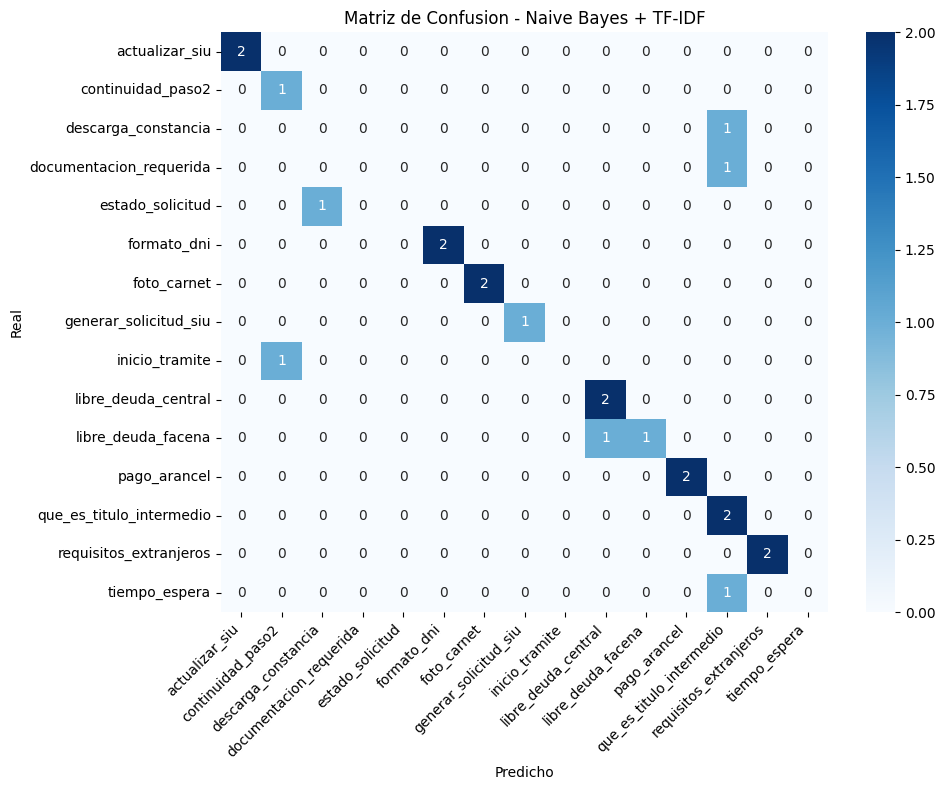

In [7]:
# Matriz de confusion - Experimento 1
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(np.unique(y_test)),
            yticklabels=sorted(np.unique(y_test)))
plt.title('Matriz de Confusion - Naive Bayes + TF-IDF')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


---
## Experimento 2: SVM Lineal + TF-IDF

**Variable controlada:** Algoritmo de clasificación
**Vectorización:** TF-IDF (misma que Exp 1)
**Modelo:** SVC con kernel lineal, C=1.0
---

In [8]:
print('='*60)
print('  EXPERIMENTO 2: SVM Lineal + TF-IDF')
print('='*60)

# Vectorizar
X_train_vec2, vec2 = vectorizar_tfidf(X_train, entrenar=True)
X_test_vec2, _ = vectorizar_tfidf(X_test, vectorizador=vec2, entrenar=False)

# Entrenar
clf_svm = SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE)
clf_svm.fit(X_train_vec2, y_train)
y_pred_svm = clf_svm.predict(X_test_vec2)

# Metricas
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f'\n>>> Accuracy: {acc_svm:.4f} ({acc_svm*100:.2f}%)')
print(f'\n>>> Reporte de clasificacion:\n')
print(classification_report(y_test, y_pred_svm, zero_division=0))


  EXPERIMENTO 2: SVM Lineal + TF-IDF
[OK] TfidfVectorizer configurado:
      max_features=500, min_df=2, ngram_range=(1, 2)
[OK] TF-IDF entrenado y transformado.
      Matriz: 89 documentos, 82 términos
      Densidad: 0.0500 (365 valores no-cero)
[OK] TF-IDF transformado (vectorizador existente).
      Matriz: 23 documentos, 82 términos
      Densidad: 0.0419 (79 valores no-cero)

>>> Accuracy: 0.8261 (82.61%)

>>> Reporte de clasificacion:

                          precision    recall  f1-score   support

          actualizar_siu       1.00      1.00      1.00         2
       continuidad_paso2       0.50      1.00      0.67         1
     descarga_constancia       0.50      1.00      0.67         1
 documentacion_requerida       0.00      0.00      0.00         1
        estado_solicitud       0.00      0.00      0.00         1
             formato_dni       1.00      1.00      1.00         2
             foto_carnet       1.00      1.00      1.00         2
   generar_solicitud_siu

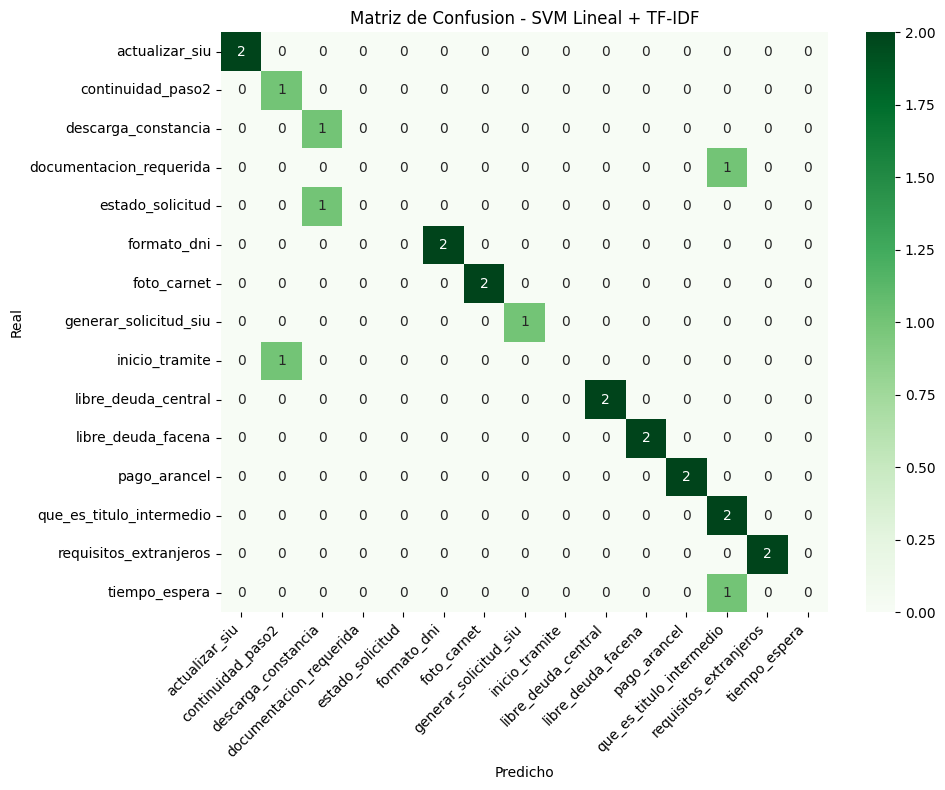

In [9]:
# Matriz de confusion - Experimento 2
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=sorted(np.unique(y_test)),
            yticklabels=sorted(np.unique(y_test)))
plt.title('Matriz de Confusion - SVM Lineal + TF-IDF')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


---
## Experimento 3: SVM + Embeddings (Sentence-Transformer)

**Variable controlada:** Representación del texto (TF-IDF -> Embeddings)
**Vectorización:** Sentence-Transformer multilingue (512 dimensiones)
**Modelo:** SVM lineal (mismo que Exp 2)
---

In [10]:
# Liberar memoria de experimentos anteriores
import gc
for _var in ['X_train_vec', 'X_test_vec', 'vectorizador', 'clf_nb',
             'clf_svm', 'X_train_vec2', 'X_test_vec2', 'vec2']:
    try:
        del globals()[_var]
    except KeyError:
        pass
gc.collect()
print("[OK] Memoria liberada de experimentos 1 y 2.")

print('='*60)
print('  EXPERIMENTO 3: SVM + Embeddings')
print('='*60)

# Cargar modelo de embeddings
modelo_emb = cargar_modelo_embeddings()

# Generar embeddings
print('\nGenerando embeddings (train)...')
X_train_emb = vectorizar_embeddings(list(X_train), modelo_emb)
print('Generando embeddings (test)...')
X_test_emb = vectorizar_embeddings(list(X_test), modelo_emb)

# Entrenar SVM con embeddings
clf_svm_emb = SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE)
clf_svm_emb.fit(X_train_emb, y_train)
y_pred_svm_emb = clf_svm_emb.predict(X_test_emb)

# Metricas
acc_svm_emb = accuracy_score(y_test, y_pred_svm_emb)
print(f'\n>>> Accuracy: {acc_svm_emb:.4f} ({acc_svm_emb*100:.2f}%)')
print(f'\n>>> Reporte de clasificacion:\n')
print(classification_report(y_test, y_pred_svm_emb, zero_division=0))


[OK] Memoria liberada de experimentos 1 y 2.
  EXPERIMENTO 3: SVM + Embeddings
[...] Cargando modelo de embeddings: distiluse-base-multilingual-cased-v2...
      (puede tardar la primera vez que descarga el modelo)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[OK] Modelo cargado: distiluse-base-multilingual-cased-v2
      Dimensiones: 512

Generando embeddings (train)...
[...] Generando embeddings para 89 textos...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

[OK] Embeddings generados: (89, 512)
Generando embeddings (test)...
[...] Generando embeddings para 23 textos...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[OK] Embeddings generados: (23, 512)

>>> Accuracy: 0.6522 (65.22%)

>>> Reporte de clasificacion:

                          precision    recall  f1-score   support

          actualizar_siu       1.00      0.50      0.67         2
       continuidad_paso2       1.00      1.00      1.00         1
     descarga_constancia       0.00      0.00      0.00         1
 documentacion_requerida       0.00      0.00      0.00         1
        estado_solicitud       0.50      1.00      0.67         1
             formato_dni       1.00      1.00      1.00         2
             foto_carnet       1.00      1.00      1.00         2
   generar_solicitud_siu       0.00      0.00      0.00         1
          inicio_tramite       1.00      1.00      1.00         1
     libre_deuda_central       0.33      0.50      0.40         2
      libre_deuda_facena       0.00      0.00      0.00         2
            pago_arancel       0.67      1.00      0.80         2
que_es_titulo_intermedio       0.67      

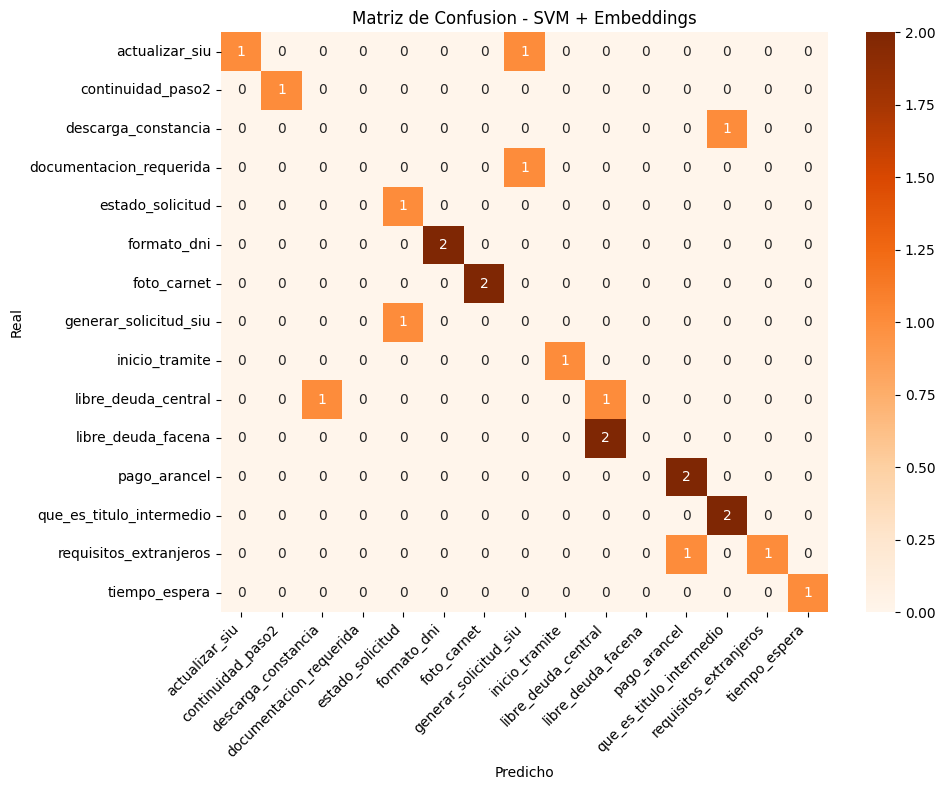

In [11]:
# Matriz de confusion - Experimento 3
cm_emb = confusion_matrix(y_test, y_pred_svm_emb)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_emb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=sorted(np.unique(y_test)),
            yticklabels=sorted(np.unique(y_test)))
plt.title('Matriz de Confusion - SVM + Embeddings')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


---
## Tabla comparativa de resultados
---

Tabla comparativa de resultados:
                 Experimento     Vectorizacion        Modelo  Accuracy
Exp. 1: Naive Bayes + TF-IDF            TF-IDF MultinomialNB    0.7391
 Exp. 2: SVM Lineal + TF-IDF            TF-IDF  SVC (linear)    0.8261
    Exp. 3: SVM + Embeddings Embeddings (512d)  SVC (linear)    0.6522


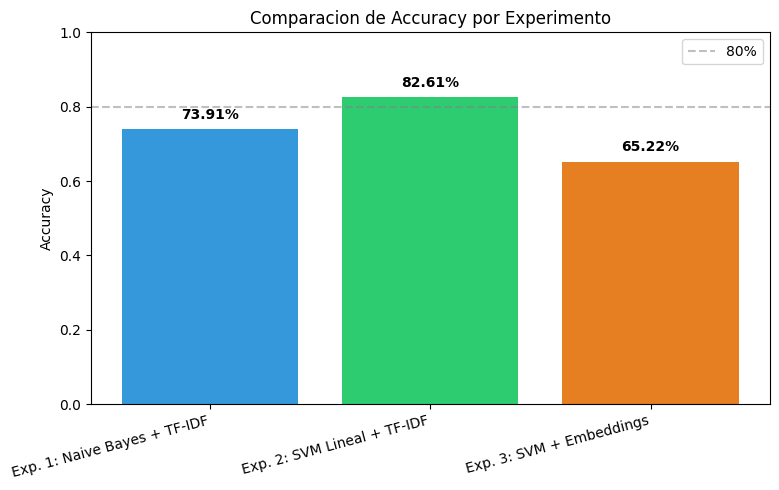

In [12]:
# Tabla de sintesis
tabla = pd.DataFrame({
    'Experimento': [
        'Exp. 1: Naive Bayes + TF-IDF',
        'Exp. 2: SVM Lineal + TF-IDF',
        'Exp. 3: SVM + Embeddings',
    ],
    'Vectorizacion': ['TF-IDF', 'TF-IDF', 'Embeddings (512d)'],
    'Modelo': ['MultinomialNB', 'SVC (linear)', 'SVC (linear)'],
    'Accuracy': [
        round(acc_nb, 4),
        round(acc_svm, 4),
        round(acc_svm_emb, 4),
    ],
})

print('Tabla comparativa de resultados:')
print(tabla.to_string(index=False))

# Grafico comparativo
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(tabla['Experimento'], tabla['Accuracy'],
              color=['#3498db', '#2ecc71', '#e67e22'])
ax.set_ylim(0, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('Comparacion de Accuracy por Experimento')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='80%')

for bar, acc in zip(bars, tabla['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{acc:.2%}', ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


---
## Conclusiones

### Resultados obtenidos

| Experimento | Accuracy |
|-------------|----------|
| Naive Bayes + TF-IDF | 73.91% |
| SVM + TF-IDF | 82.61% |
| SVM + Embeddings | 65.22% |

### Analisis

- SVM supera a Naive Bayes cuando se usa TF-IDF: SVM encuentra el hiperplano optimo de separacion, mientras que Naive Bayes asume independencia condicional entre features.
- Los embeddings capturan significado semantico, lo que podria ayudar a generalizar mejor con variaciones de lenguaje.

### Limitaciones

- Dataset pequeno (112 preguntas, 23 en test): los resultados deben tomarse con cautela.
- Algunas clases tienen solo 1 muestra en test, lo que hace que las metricas por clase sean ruidosas.
- Un dataset mas grande (200-300 preguntas) daria resultados mas confiables.

### Trabajos futuros

- Agregar mas variaciones de preguntas por intencion.
- Probar otros modelos (Random Forest, Regresion Logistica).
- Ajustar hiperparametros con GridSearchCV.
- Implementar la interfaz del chatbot.

---
*Notebook generado automaticamente por el pipeline de desarrollo del proyecto.*